In [32]:
import numpy as np
from scipy.stats import norm as norm

In [ ]:
def portfolio_value_increment(t, s):
    """
    Function to return the portfolio increment deltaV(t,s)
    = V(s) - V(t) + TF(t,s)
    Where V(s) is the portfolio value at time s, and TF(t,s) is the value at time s
    of all trades made in the period t to s.
    """
    return np.random.standard_normal()

def t_distribution_portfolio_increment(initial_value, mu, sigma, degrees_of_freedom, MPOR, samples):
    """
    Function that takes daily returns according to a t-distribution, and returns the change in value of
    a sample path at the end of the MPOR (margin period of risk) from the starting value

    mu controls the drift of the distribution, sigma the variance, degrees_of_freedom the number of
    degrees of freedom of each of the t-distribution increments, and MPOR (margin period of risk) 
    the total number of days over the margin period of risk.
    """
    rng = np.random.default_rng()
    t_samples = rng.standard_t(degrees_of_freedom, size = (samples, MPOR))

    log_returns = sigma * t_samples + mu

    overall_return = log_returns.sum(axis = 1)

    return (np.exp(overall_return) - 1) * initial_value

def initial_margin():
    """
    Returns the initial margin, at time t, that is available until the
    next margin update, over the Margin Period of Risk.
    """
    return 0

In [34]:
def get_annual_default_intensity(MPOR, default_probability):
    """
    Reverse default probability over MPOR (margin period of risk) assuming a Poisson model
    with constant default intensity.
    """
    return - (260. / MPOR) * np.log(1 - default_probability)

def get_default_probability(MPOR, default_intensity):
    """
    Obtain default probability over MPOR (margin period of risk), from default intensity
    under a Poisson model
    """
    return 1 - np.exp(-default_intensity * MPOR/260.)

In [35]:
def default_probability_estimate(MPOR, volatility, margin):
    """
    Returns a crude estimate for the probability of default over the MPOR. 
    
    We calculate assuming that the underlying assets follow a lognormal 
    distribution with no drift, with volatility the same as the 
    underlying stock, and that debt is a fixed margin percentage of the
    portfolio value at the start of the margin period of risk.

    The estimate is then returned as the probability the assets value
    falls below the debt at the end of the MPOR (margin period of risk)

    MPOR, the number of business days in the margin period of risk.
    volatility, the annualised volatility of the company in question
    margin, the percentage of the asset position held as margin
    """
    rescaled_vol = volatility * np.sqrt(MPOR / 252)
    return norm.cdf((np.log(margin) + rescaled_vol * rescaled_vol * 0.5)/rescaled_vol)

print(default_probability_estimate(252, 0.7, 0.2))

0.025635950491309734


In [36]:
def sort_arrays_by_increment_size(increment_array, margin_array):
    """
    Takes a numpy array of portfolio increment values, and sorts them in increasing order,
    also sorting the margin array at the same time (so that the same margin array value)
    is associated with it's corresponding unsorted increment array value
    """

    indicies = np.argsort(increment_array)
    return increment_array[indicies], margin_array[indicies]

def average_cumulative_distribution(v,portfolio_array):
    """
    Takes a numpy array of portfolio increment values, and a sample value, and returns 
    the implied discrete cumulative distribution function of the portfolio values, 
    evaluated at v.

    The convention here is if the value v entered is one of the sampled values, is to 
    return the average of the function immediately preceding and following the value
    v, as opposed to a standard discrete cumaltive distribution function.
    """

    return None


def cumulative_distribution(v, portfolio_array):
    """
    Takes a numpy array of portfolio increment values, and a sample value, and returns 
    the implied discrete cumulative distribution function of the portfolio values, 
    evaluated at v.
    """
    return (portfolio_array <= v).mean()


In [37]:
def normal_portfolio_value(v, portfolio_array):
    """
    Takes a numpy array of portfolio incement values, and a sample value, and returns
    the value of the normal random variable, Z, that corresponds to the extremeness
    of the sample value v on the sample cumulative distribution function from the
    portfolio array.
    """
    return norm.ppf(cumulative_distribution(v, portfolio_array))

In [38]:
def path_weight(Z, rho, unconditional_default_probability):
    """
    Function that takes the normal portfolio value, Z, a correlation parameter rho,
    and the unconditional default probability of B over the margin period of risk,
    and returns the weight assigned to the path that generated Z in the calculation
    of the expected exposure.
    """
    return (1. / unconditional_default_probability) * norm.cdf((norm.ppf(unconditional_default_probability) + rho * Z) / np.sqrt(1. - rho * rho)) 

In [39]:
def sorted_array_path_weight(m, sorted_increment_array, rho, unconditional_default_probability):
    """
    Function that takes the normal portfolio value, Z(m), a correlation parameter rho,
    and the unconditional default probability of B over the margin period of risk,
    and returns the weight assigned to the path that generated Z in the calculation
    of the expected exposure.

    Z(m) is the m'th largest value in the sorted_increment_array, a numpy array of 
    the sorted increments of portfolio value moves over the margin period of risk.
    """
    Z = norm.ppf((m - 0.5)/sorted_increment_array.len())
    return path_weight(Z, rho, unconditional_default_probability)

def sorted_array_path_weights(sorted_increment_array, rho, unconditional_default_probability):
    """
    Function that takes the sorted increment array, a correlation parameter rho,
    and the unconditional default probability of B over the margin period of risk,
    and returns a numpy array of weight assigned to each path that generated the 
    sorted increments for the calculation of expected exposure.

    Z(m) is the m'th largest value in the sorted_increment_array, a numpy array of 
    the sorted increments of portfolio value moves over the margin period of risk.
    """
    M = sorted_increment_array.size
    m_s = np.linspace(1, M, M)
    Z = norm.ppf((m_s - 0.5)/ M)
    return (1. / unconditional_default_probability) * norm.cdf((norm.ppf(unconditional_default_probability) + rho * Z) / np.sqrt(1. - rho * rho)) 



In [40]:
def pykhtin_simple_expected_exposure(portfolio_value_increment_array, initial_margin_array, rho, unconditional_default_probability):
    """
    Calculates the expected exposure according to Pykthin, with weighted paths
    according to a simple Gaussian Copula to connect probability of default
    over the margin period of risk with the change of the portfolio value.

    Assumes that portfolio evolution over time is independent of the probability
    of the default of the counterparty. E.g. that large portfolio values don't
    increase the probability of default.
    """

    sorted_increment_array, sorted_margin_array = sort_arrays_by_increment_size(portfolio_value_increment_array, initial_margin_array)

    weights = sorted_array_path_weights(sorted_increment_array, rho, unconditional_default_probability)

    return (weights * (np.maximum(sorted_increment_array - sorted_margin_array, 0))).mean()


def pykhtin_simple_potential_future_exposure(portfolio_value_increment_array, initial_margin_array, rho, unconditional_default_probability, alpha):
    """
    Calculates the potential future exposure, based on paper Pykthin, with weighted paths
    according to a simple Gaussian Copula to connect probability of default
    over the margin period of risk with the change of the portfolio value.

    Assumes that portfolio evolution over time is independent of the probability
    of the default of the counterparty. E.g. that large portfolio values don't
    increase the probability of default.
    """

    sorted_increment_array, sorted_margin_array = sort_arrays_by_increment_size(portfolio_value_increment_array, initial_margin_array)

    weights = sorted_array_path_weights(sorted_increment_array, rho, unconditional_default_probability)

    # Take an upper triangular matrix, and multiply it by the weights to obtain an array containing cumulative weights
    # With just the final weight contained in the first entry, the final two weights summed in the second etc.
    cumulative_weights = np.cumsum(weights)
    
    # We iterate over the cumulative weights to identify the index which contains the final cumulative weight bigger than the alpha confidence
    # level
    M = sorted_increment_array.size
    index = M - 1
    rescaled_alpha =  M * alpha # alpha is supplied as a percentage, but the weights are absolute
    for weight in np.flip(cumulative_weights):
        if weight < rescaled_alpha:
            return (sorted_increment_array[index] - sorted_margin_array[index])
        index -= 1

    # Return the future exposure that corresponds to this index
    return (sorted_increment_array[0] - sorted_margin_array[0])

In [41]:
portfolio_values = np.random.standard_normal(1000)
margins = np.full((1000), norm.ppf(0.99))

rhos = np.linspace(0, 1, 20)
exposures_99 = np.zeros(rhos.shape)
for i in range(0,len(rhos)):
    exposures_99[i] = pykhtin_simple_expected_exposure(portfolio_values, margins, rhos[i], 0.1)


margins = np.full((1000), norm.ppf(0.95))
exposures_95 = np.zeros(rhos.shape)
for i in range(0,len(rhos)):
    exposures_95[i] = pykhtin_simple_expected_exposure(portfolio_values, margins, rhos[i], 0.1)

margins = np.full((1000), 0)
exposures_no_margin = np.zeros(rhos.shape)
for i in range(0,len(rhos)):
    exposures_no_margin[i] = pykhtin_simple_expected_exposure(portfolio_values, margins, rhos[i], 0.1)
    

C:\Users\tzp25\AppData\Local\Temp\ipykernel_33036\969956465.py:27: RuntimeWarning: divide by zero encountered in divide
  return (1. / unconditional_default_probability) * norm.cdf((norm.ppf(unconditional_default_probability) + rho * Z) / np.sqrt(1. - rho * rho))


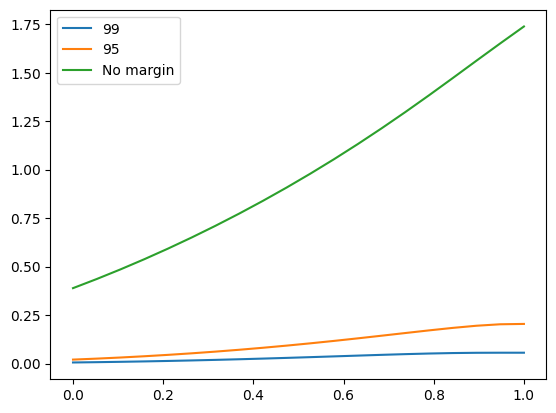

In [42]:
import matplotlib.pyplot as plt
plt.plot(rhos, exposures_99, label = "99")
plt.plot(rhos, exposures_95, label = "95")
plt.plot(rhos, exposures_no_margin, label = "No margin")
plt.legend()
plt.show()


In [43]:
portfolio_values = np.random.standard_normal(100000)
rhos = np.linspace(0, 1, 20)
margins = np.full((100000), 0)

pfe_99 = np.zeros(rhos.shape)
for i in range(0,len(rhos)):
    pfe_99[i] = pykhtin_simple_potential_future_exposure(portfolio_values, margins, rhos[i], 0.1, 0.99)

pfe_95 = np.zeros(rhos.shape)
for i in range(0,len(rhos)):
    pfe_95[i] = pykhtin_simple_potential_future_exposure(portfolio_values, margins, rhos[i], 0.1, 0.95)

C:\Users\tzp25\AppData\Local\Temp\ipykernel_33036\969956465.py:27: RuntimeWarning: divide by zero encountered in divide
  return (1. / unconditional_default_probability) * norm.cdf((norm.ppf(unconditional_default_probability) + rho * Z) / np.sqrt(1. - rho * rho))


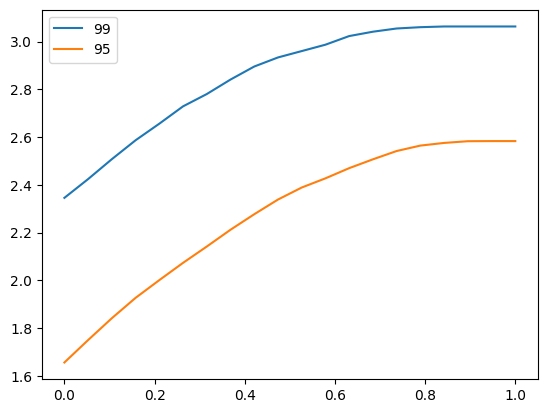

In [44]:
plt.plot(rhos, pfe_99, label = "99")
plt.plot(rhos, pfe_95, label = "95")
plt.legend()
plt.show()

In [45]:
# From the default values in Anfuso's paper, obtain a default intensity
anfuso_default_probability = 0.03
anfuso_default_MPOR = 5
implied_default_intensity = get_annual_default_intensity(anfuso_default_MPOR, anfuso_default_probability)

In [ ]:
credit_suisse_portfolio_value = 16921696044
MPOR = 10
t_mu = 0
t_sigma = 0.01
t_freedom = 4.32
samples = 100000
margin_percentage = 0.1042 * 8939000000/20000000000
anfuso_implied_default_probability = get_default_probability(MPOR, implied_default_intensity)

rhos = np.linspace(0, 1, 20)

portfolio_increments = t_distribution_portfolio_increment(credit_suisse_portfolio_value, t_mu, t_sigma, t_freedom, MPOR, samples)
margins = np.full((samples), credit_suisse_portfolio_value * margin_percentage)

pfe_99 = np.zeros(rhos.shape)
for i in range(0,len(rhos)):
    pfe_99[i] = pykhtin_simple_potential_future_exposure(portfolio_increments, margins, rhos[i], anfuso_implied_default_probability, 0.99)

pfe_95 = np.zeros(rhos.shape)
for i in range(0,len(rhos)):
    pfe_95[i] = pykhtin_simple_potential_future_exposure(portfolio_increments, margins, rhos[i], anfuso_implied_default_probability, 0.95)



C:\Users\tzp25\AppData\Local\Temp\ipykernel_33036\969956465.py:27: RuntimeWarning: divide by zero encountered in divide
  return (1. / unconditional_default_probability) * norm.cdf((norm.ppf(unconditional_default_probability) + rho * Z) / np.sqrt(1. - rho * rho))


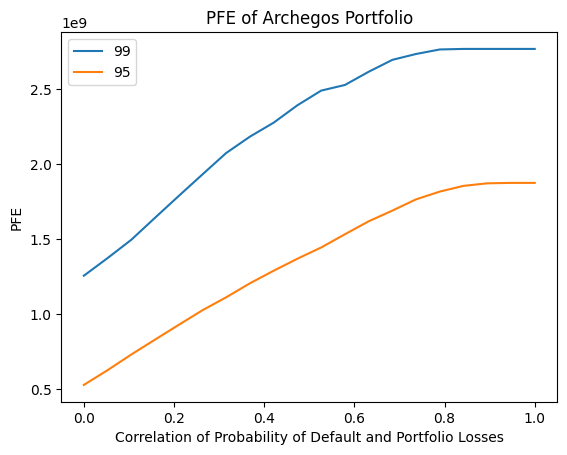

In [68]:
plt.plot(rhos, pfe_99, label = "99")
plt.plot(rhos, pfe_95, label = "95")
plt.title("PFE of Archegos Portfolio")
plt.xlabel("Correlation of Probability of Default and Portfolio Losses")
plt.ylabel("PFE")
plt.legend()
plt.show()

In [66]:
exposures = np.zeros(rhos.shape)
for i in range(0,len(rhos)):
    exposures[i] = pykhtin_simple_expected_exposure(portfolio_increments, margins, rhos[i], anfuso_implied_default_probability)

C:\Users\tzp25\AppData\Local\Temp\ipykernel_33036\969956465.py:27: RuntimeWarning: divide by zero encountered in divide
  return (1. / unconditional_default_probability) * norm.cdf((norm.ppf(unconditional_default_probability) + rho * Z) / np.sqrt(1. - rho * rho))


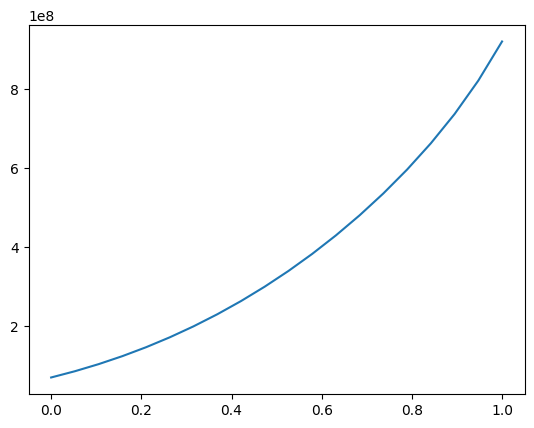

In [67]:
plt.plot(rhos, exposures, label = "Expected Exposures")
plt.show()

C:\Users\tzp25\AppData\Local\Temp\ipykernel_33036\1827330925.py:13: RuntimeWarning: divide by zero encountered in divide
  return (1. / unconditional_default_probability) * norm.cdf((norm.ppf(unconditional_default_probability) + rho * Z) / np.sqrt(1. - rho * rho))


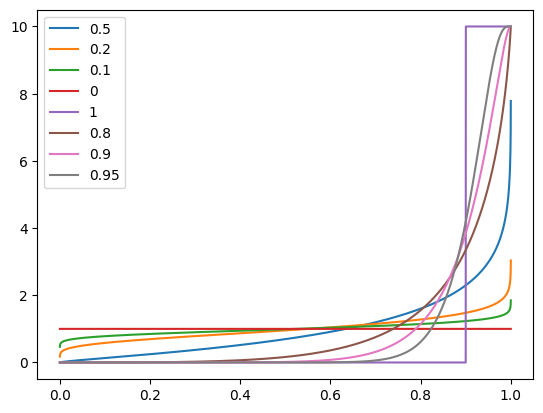

In [63]:
def path_weight_test(M, rho, unconditional_default_probability):
    """
    Function that takes the sorted increment array, a correlation parameter rho,
    and the unconditional default probability of B over the margin period of risk,
    and returns a numpy array of weight assigned to each path that generated the 
    sorted increments for the calculation of expected exposure.

    Z(m) is the m'th largest value in the sorted_increment_array, a numpy array of 
    the sorted increments of portfolio value moves over the margin period of risk.
    """
    m_s = np.linspace(1, M, M)
    Z = norm.ppf((m_s - 0.5)/ M)
    return (1. / unconditional_default_probability) * norm.cdf((norm.ppf(unconditional_default_probability) + rho * Z) / np.sqrt(1. - rho * rho)) 

M = 10000

m_s = np.linspace(1, M, M)

weights = path_weight_test(M, 0.5, 0.1)

plt.plot(m_s/M, weights, label = "0.5")

weights = path_weight_test(M, 0.2, 0.1)
plt.plot(m_s/M, weights, label = "0.2")

weights = path_weight_test(M, 0.1, 0.1)
plt.plot(m_s/M, weights, label = "0.1")

weights = path_weight_test(M, 0, 0.1)
plt.plot(m_s/M, weights, label = "0")

weights = path_weight_test(M, 1, 0.1)
plt.plot(m_s/M, weights, label = "1")

weights = path_weight_test(M, 0.8, 0.1)
plt.plot(m_s/M, weights, label = "0.8")

weights = path_weight_test(M, 0.9, 0.1)
plt.plot(m_s/M, weights, label = "0.9")
weights = path_weight_test(M, 0.95, 0.1)
plt.plot(m_s/M, weights, label = "0.95")


plt.legend()
plt.show()